# Dark-matter quantum-sensor response analysis

Forward + inverse analysis of the detector response, organised **by detector**
and, within each, **by velocity-distribution model**. Same pipeline throughout
(load Mathematica response matrix -> forward model `exposure * M @ eta` ->
recover the monotone non-negative flux `x(v_min)`); only two things change:

- **detector** (`material`): **TES (Al)** -- Mermin, 0.1 eV threshold, fine `R10`;
  **MKID (TiN)** -- Lindhard, 0.2 eV threshold, fine `R9`.
- **velocity model**: **Halo** -- standard halo (SHM, `v0=238, ve=250, vesc=544`
  km/s); **pure dark disk** -- same DM density, colder (`v0=70, ve=100,
  vesc=694`). The actual **best-fit uses a mixture** `eta = (1-p)*Halo + p*Disk`
  with disk fraction `p`; because both components carry the same local DM
  density, the mixture's density equals 100% SHM for any `p`. A third model,
  **Bound** (Earth-captured thermal DM), is a separate dense population
  (`rho_b`, isotropic, `vesc=11.2` km/s) -- only the heaviest mass (1 GeV) has
  any signal, since the bound DM is too slow to reach higher `v_min`.

The mixture sections sweep `p` over `DISK_FRACTIONS` and overlay, on each fit,
the **100% SHM** halo and the **`p` x pure disk** component for reference.


In [59]:
%matplotlib inline
import matplotlib.pyplot as plt
from quantum_sensor import DarkMatterQuantumAnalysis, RunConfig

MASS_LABELS = {'1': '10 MeV', '2': '100 MeV', '3': '1 GeV'}
DETECTOR = {'Al': 'TES', 'TiN': 'MKID'}
# Dark-disk mixing fractions p for the best-fit eta = (1-p)*Halo + p*Disk.
DISK_FRACTIONS = (0.05, 0.25)


def run_masses(material, q='0', nbins=5, eta='Halo', background='none',
               disk_fraction=None, masses=('1', '2', '3'), solver='osqp', save=True):
    """Run the forward+inverse analysis for several DM masses.

    Shows one combined figure (the masses side by side). When ``save=True``
    (default) each run is ALSO saved on its own -- flux.csv plus an individual
    flux.pdf -- into its per-run folder
    results/<DET>/bkg-<background>/<material>_q<q>_M<mass>_R<nbins>_<eta>/, so
    every type is stored separately regardless of the combined display.
    """
    fig, axes = plt.subplots(1, len(masses), figsize=(6 * len(masses), 5), squeeze=False)
    for ax, mass in zip(axes[0], masses):
        a = DarkMatterQuantumAnalysis(
            RunConfig(material=material, q=q, mass=mass, nbins=nbins,
                      eta=eta, disk_fraction=disk_fraction, background=background))
        flux = a.optimize(solver=solver)
        print('signal     :', a.signal)
        print('background :', a.background)

        if save:
            a.save_flux()                     # flux.csv in this run's own folder
            sfig, sax = plt.subplots(figsize=(8, 6))
            a.plot(save=True, ax=sax)         # individual flux.pdf next to the CSV
            plt.close(sfig)                   # keep only the combined figure on screen

        a.plot(save=False, ax=ax)             # combined panel (display only)
        ax.set_title(f'{material} ({DETECTOR[material]}), $m_\\chi$ = {MASS_LABELS[mass]}',
                     fontsize=13)
        print(f'{material} q{q} M{mass} R{nbins}: {a.n_ebins} E-bins x '
              f'{a.n_vmin} v_min bins, peak flux {flux.max():.2e}')
    model = eta if disk_fraction is None else f'mix {round(disk_fraction*100)}% disk'
    fig.suptitle(f'{material} ({DETECTOR[material]}), q{q}, R{nbins}, {model}, bkg={background}',
                 fontsize=14)
    plt.tight_layout(); plt.show()


# TES (Al)

## Halo (SHM) — reference

### Heavy mediator (q0), 5 energy bins

signal     : [1.19744363 2.35395732 3.4758735  4.4542822  5.48386654]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_Halo/flux.pdf
Al q0 M1 R5: 5 E-bins x 126 v_min bins, peak flux 7.83e-31
signal     : [0.11750272 0.24435997 0.34638123 0.47692563 0.57408796]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_Halo/flux.pdf
Al q0 M2 R5: 5 E-bins x 59 v_min bins, peak flux 8.26e-32
signal     : [0.0121961  0.02369161 0.03610597 0.04627132 0.05625323]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_Halo/flux.pdf
Al q0 M3 R5: 5 E-bins x 59 v_min bins, peak flux 8.28e-33


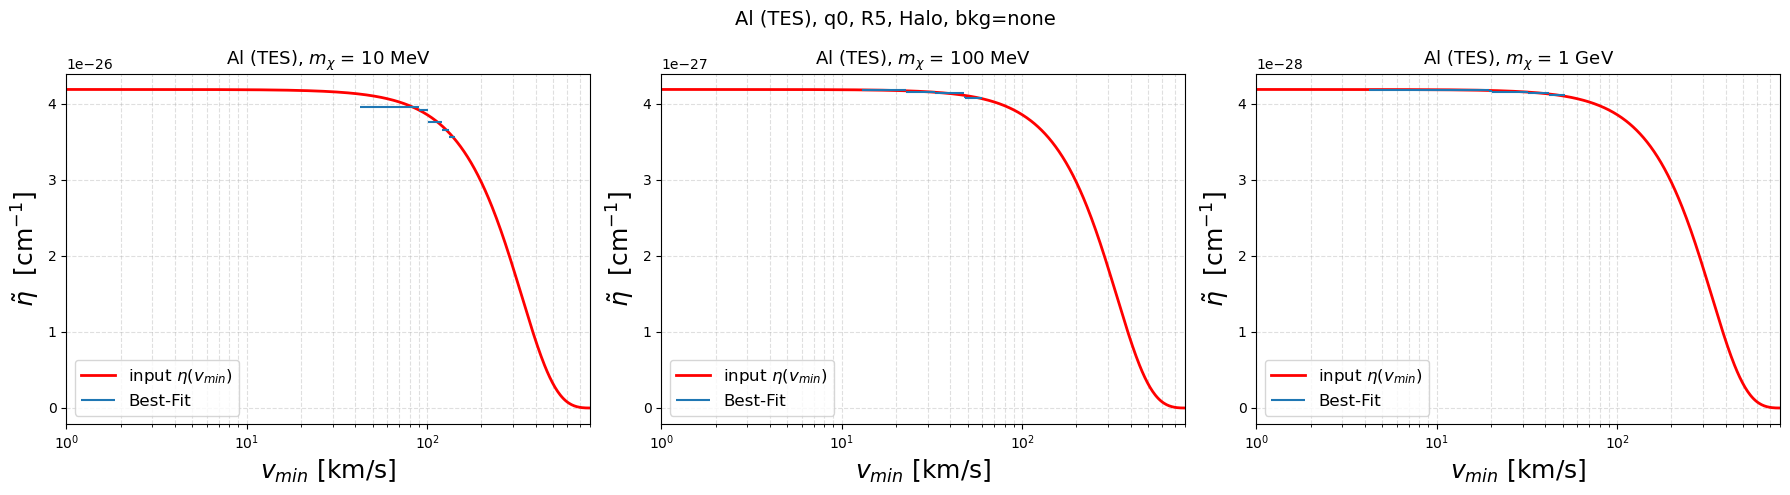

In [60]:
run_masses('Al', q='0', nbins=5, eta='Halo')

### Light mediator (q2), 5 energy bins

signal     : [1.15714707 2.18615664 3.07013782 3.80930618 4.49828845]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_Halo/flux.pdf
Al q2 M1 R5: 5 E-bins x 174 v_min bins, peak flux 8.01e-31
signal     : [0.10780587 0.20727324 0.29793605 0.37814688 0.45185219]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_Halo/flux.pdf
Al q2 M2 R5: 5 E-bins x 176 v_min bins, peak flux 8.24e-32
signal     : [0.01073901 0.02064983 0.02970971 0.03775877 0.0449672 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_Halo/flux.pdf
Al q2 M3 R5: 5 E-bins x 183 v_min bins, peak flux 8.26e-33


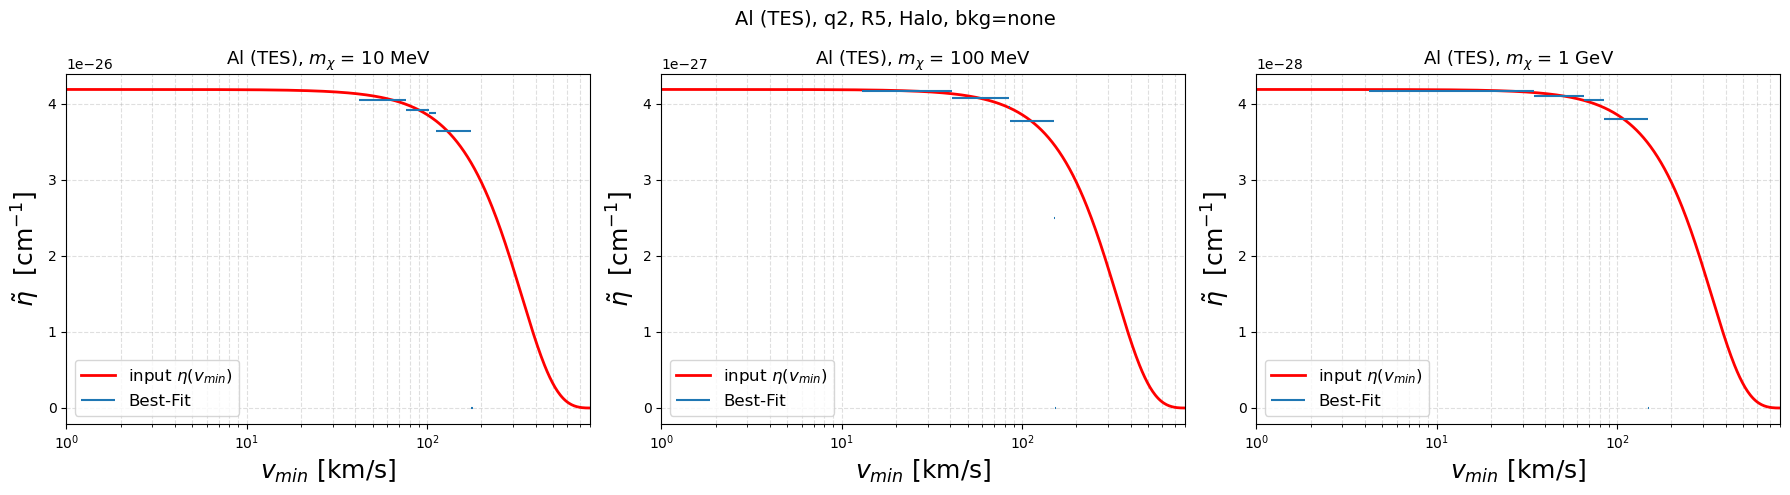

In [61]:
run_masses('Al', q='2', nbins=5, eta='Halo')

### Heavy mediator (q0), 10 energy bins

signal     : [0.46556721 0.78427083 1.07336726 1.39356001 1.66362135 1.97341788
 2.19051142 2.48663779 2.78858613 3.09641457]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_Halo/flux.pdf
Al q0 M1 R10: 10 E-bins x 129 v_min bins, peak flux 7.94e-31
signal     : [0.051551   0.08337093 0.11684675 0.14270309 0.17424546 0.20902929
 0.22378018 0.25617825 0.2893215  0.32219294]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_Halo/flux.pdf
Al q0 M2 R10: 10 E-bins x 62 v_min bins, peak flux 8.27e-32
signal     : [0.00460768 0.00762541 0.01152929 0.01422413 0.01682931 0.01942626
 0.02341464 0.02597938 0.02856339 0.03113985]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R10

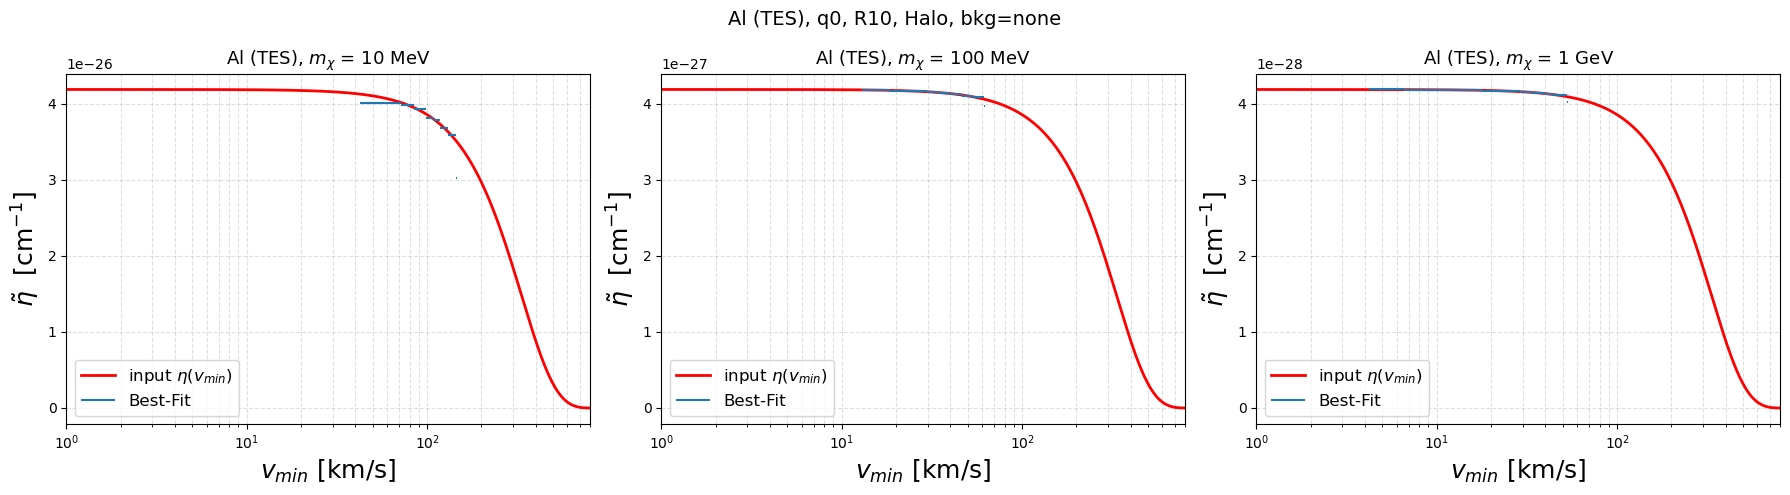

In [62]:
run_masses('Al', q='0', nbins=10, eta='Halo')

### Light mediator (q2), 10 energy bins

signal     : [0.45367126 0.74716635 1.01426416 1.25731941 1.48493395 1.71279016
 1.90711187 2.08738652 2.26086452 2.43544569]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_Halo/flux.pdf
Al q2 M1 R10: 10 E-bins x 181 v_min bins, peak flux 8.08e-31
signal     : [0.0432528  0.07015008 0.09658513 0.12145221 0.14431427 0.16674257
 0.18815162 0.20874954 0.22754982 0.24529931]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_Halo/flux.pdf
Al q2 M2 R10: 10 E-bins x 184 v_min bins, peak flux 8.30e-32
signal     : [0.00419731 0.00697987 0.009613   0.01197875 0.01438507 0.01663192
 0.01877975 0.02073494 0.02274264 0.02453323]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R1

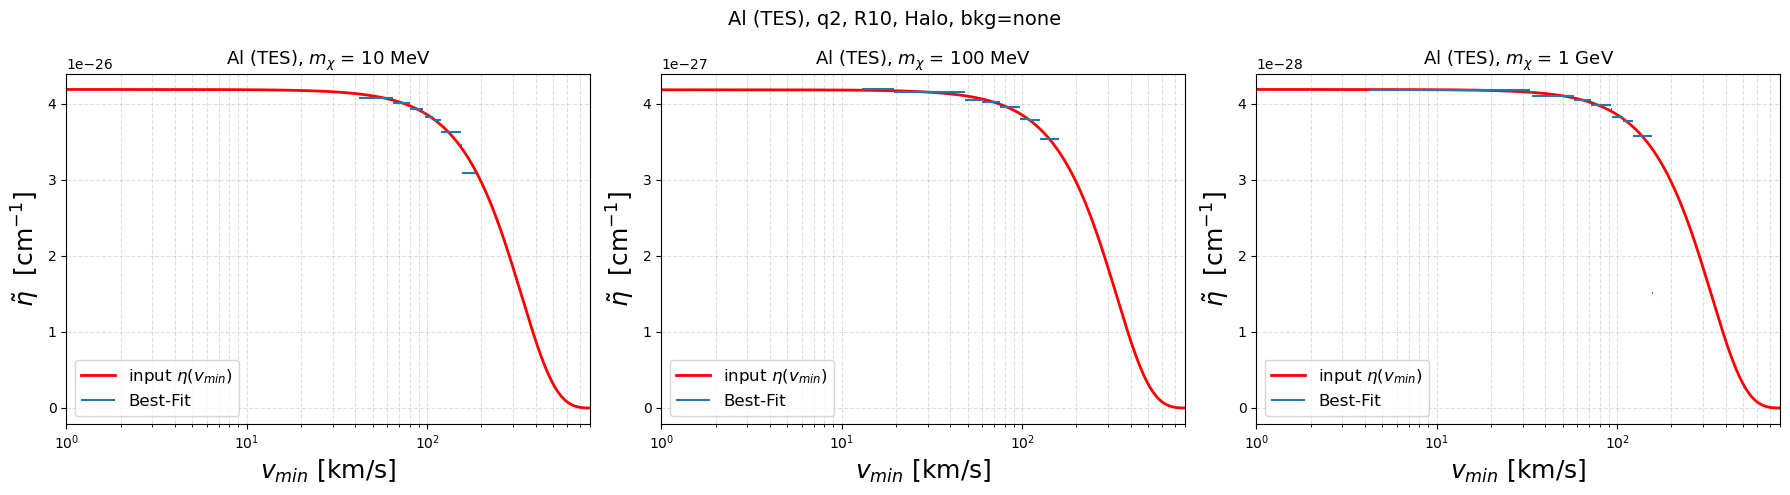

In [63]:
run_masses('Al', q='2', nbins=10, eta='Halo')

## Mixture (best-fit) — sweep dark-disk fraction

`eta = (1-p)*Halo + p*Disk`. Each figure overlays 100% SHM (gray) and `p` x pure disk (green).

### Heavy mediator (q0), 5 energy bins

signal     : [1.25022514 2.42507602 3.52813433 4.45791922 5.41950156]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_mix5/flux.pdf
Al q0 M1 R5: 5 E-bins x 126 v_min bins, peak flux 8.21e-31
signal     : [0.12757136 0.26467317 0.37410704 0.51334943 0.61574374]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_mix5/flux.pdf
Al q0 M2 R5: 5 E-bins x 59 v_min bins, peak flux 8.97e-32
signal     : [0.01325951 0.02573843 0.03917342 0.05011774 0.06079702]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_mix5/flux.pdf
Al q0 M3 R5: 5 E-bins x 59 v_min bins, peak flux 9.00e-33


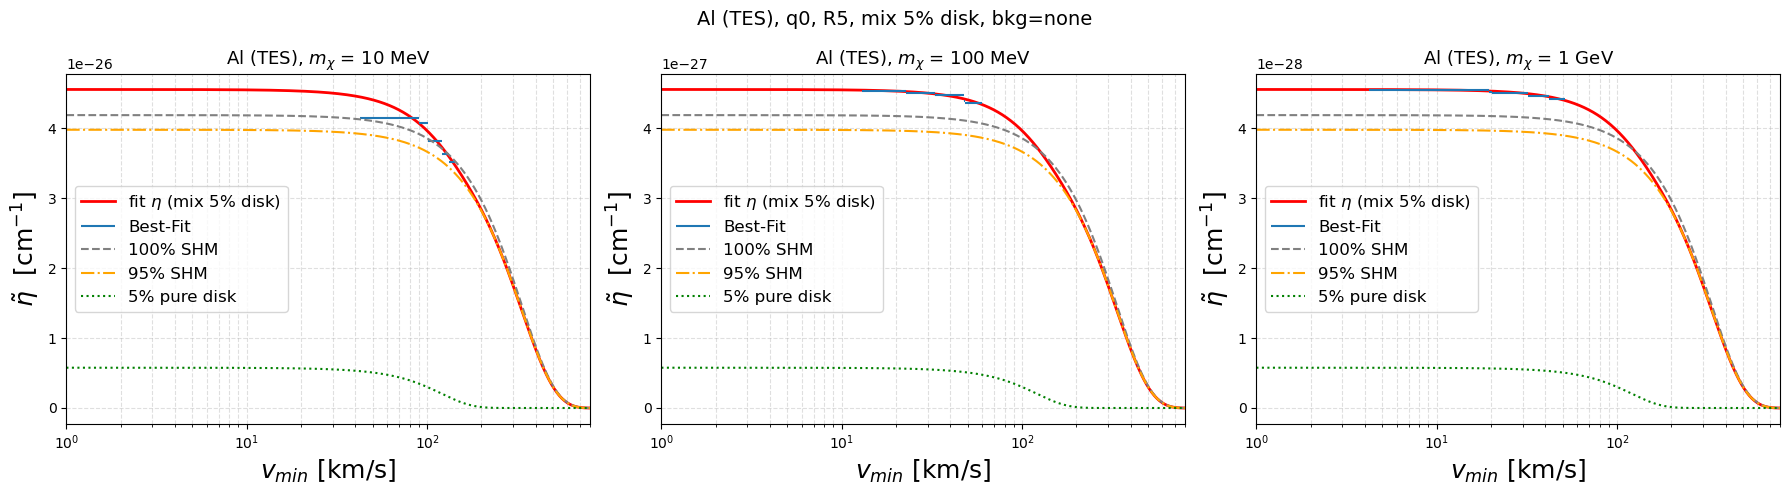

signal     : [1.46135115 2.70955082 3.73717766 4.4724673  5.16204166]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_mix25/flux.pdf
Al q0 M1 R5: 5 E-bins x 126 v_min bins, peak flux 9.72e-31
signal     : [0.1678459  0.34592598 0.48501028 0.65904463 0.78236688]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_mix25/flux.pdf
Al q0 M2 R5: 5 E-bins x 59 v_min bins, peak flux 1.18e-31
signal     : [0.01751313 0.03392574 0.05144322 0.0655034  0.07897216]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_mix25/flux.pdf
Al q0 M3 R5: 5 E-bins x 59 v_min bins, peak flux 1.19e-32


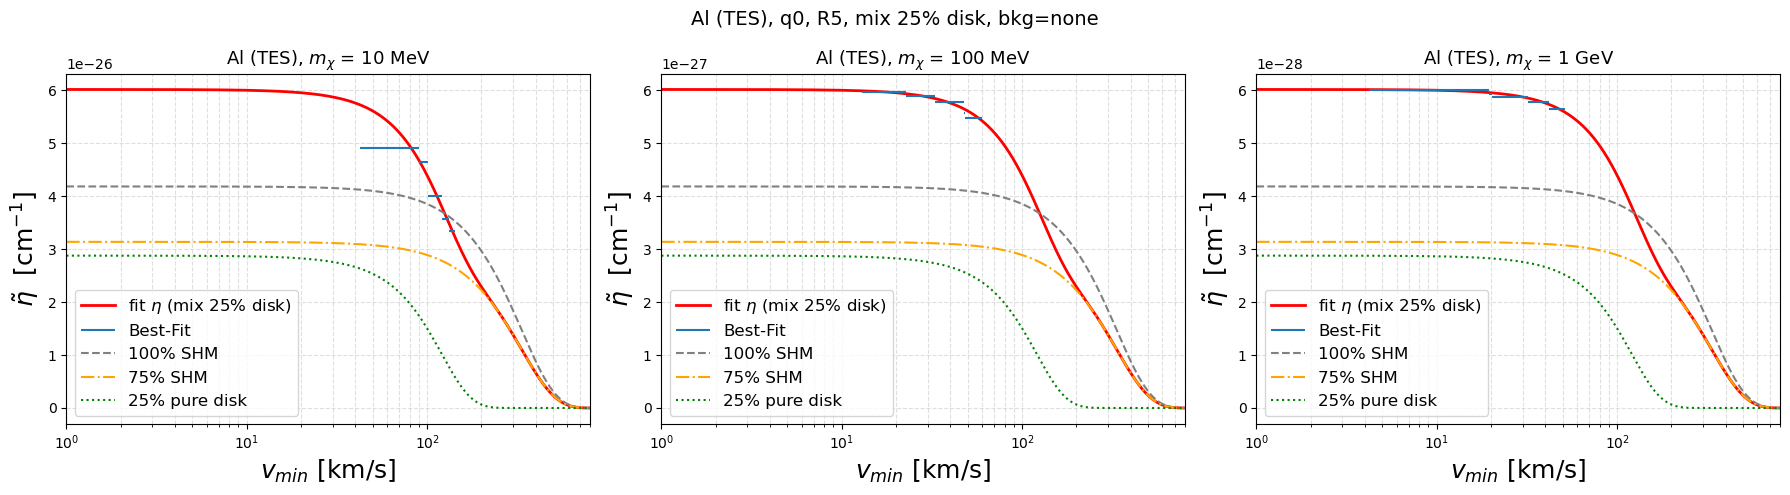

In [64]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='0', nbins=5, disk_fraction=p)

### Light mediator (q2), 5 energy bins

signal     : [1.23010861 2.27180184 3.11977576 3.79625126 4.41211157]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_mix5/flux.pdf
Al q2 M1 R5: 5 E-bins x 174 v_min bins, peak flux 8.51e-31
signal     : [0.11685265 0.22302894 0.31678814 0.39611507 0.46567906]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_mix5/flux.pdf
Al q2 M2 R5: 5 E-bins x 176 v_min bins, peak flux 8.93e-32
signal     : [0.01165127 0.02226126 0.03168048 0.03970063 0.04655518]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_mix5/flux.pdf
Al q2 M3 R5: 5 E-bins x 183 v_min bins, peak flux 8.97e-33


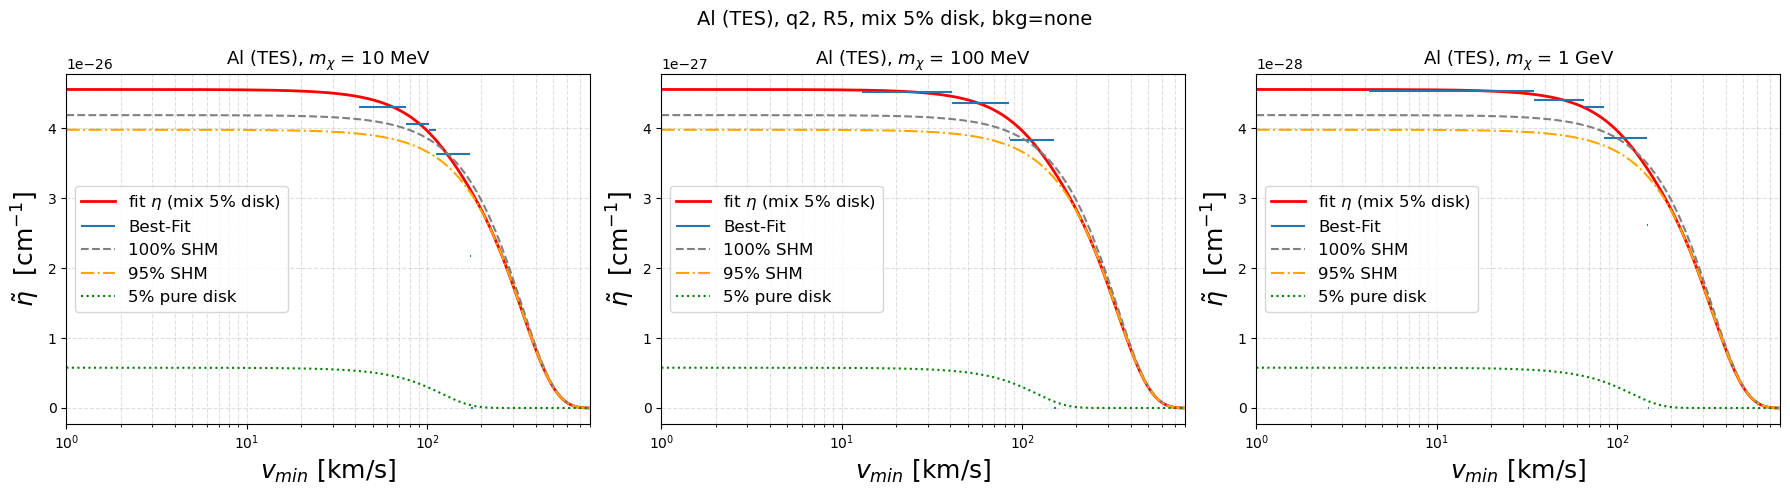

signal     : [1.52195476 2.61438262 3.31832751 3.74403158 4.06740406]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_mix25/flux.pdf
Al q2 M1 R5: 5 E-bins x 174 v_min bins, peak flux 1.05e-30
signal     : [0.15303976 0.28605174 0.3921965  0.46798782 0.52098653]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_mix25/flux.pdf
Al q2 M2 R5: 5 E-bins x 176 v_min bins, peak flux 1.17e-31
signal     : [0.01530031 0.02870698 0.03956356 0.04746807 0.05290708]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_mix25/flux.pdf
Al q2 M3 R5: 5 E-bins x 183 v_min bins, peak flux 1.18e-32


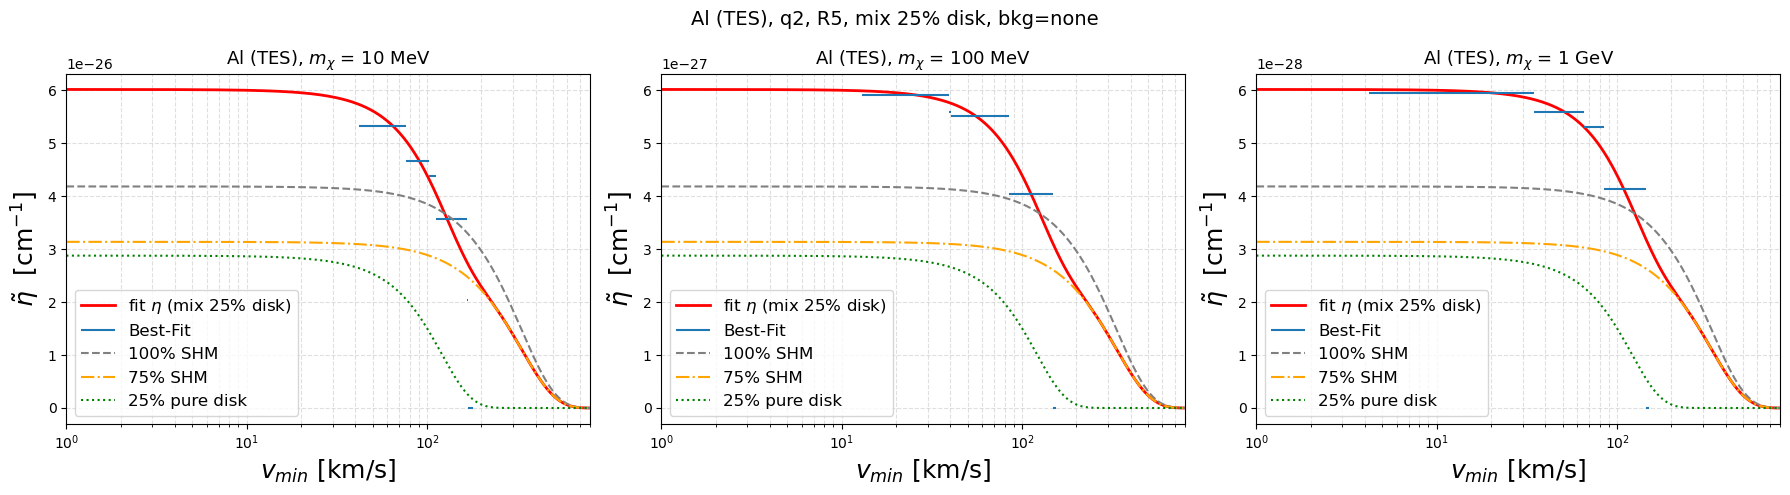

In [65]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='2', nbins=5, disk_fraction=p)

### Heavy mediator (q0), 10 energy bins

signal     : [0.48802585 0.81692928 1.11042538 1.43059311 1.69538812 1.99566545
 2.19984361 2.47983365 2.76319565 3.05041781]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_mix5/flux.pdf
Al q0 M1 R10: 10 E-bins x 129 v_min bins, peak flux 8.41e-31
signal     : [0.0559916  0.09046543 0.1266375  0.15445514 0.18831391 0.22554262
 0.24109313 0.2755079  0.31056345 0.34516818]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_mix5/flux.pdf
Al q0 M2 R10: 10 E-bins x 62 v_min bins, peak flux 8.98e-32
signal     : [0.00501002 0.00828916 0.01252727 0.01544789 0.01826635 0.02107025
 0.02536946 0.028121   0.03088422 0.03362891]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R10

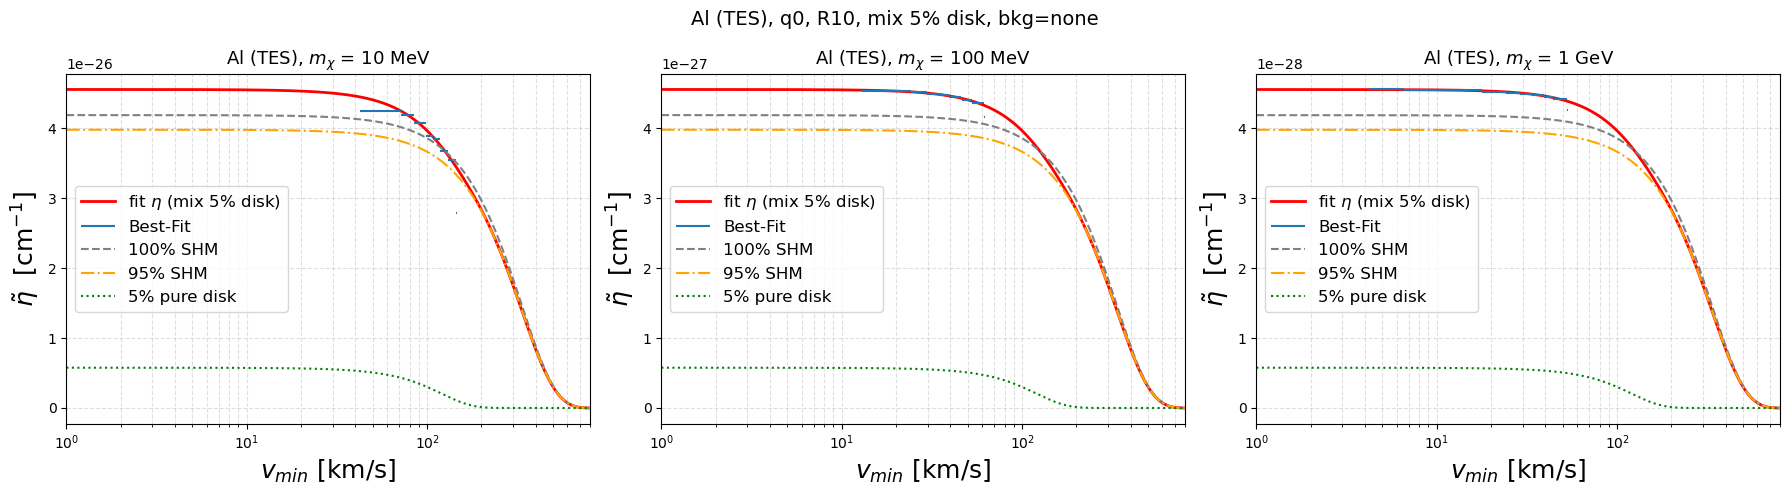

signal     : [0.57786042 0.94756312 1.25865788 1.5787255  1.82245521 2.08465572
 2.23717238 2.45261713 2.66163373 2.8664308 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_mix25/flux.pdf
Al q0 M1 R10: 10 E-bins x 129 v_min bins, peak flux 1.03e-30
signal     : [0.073754   0.11884344 0.16580048 0.20146338 0.24458773 0.29159597
 0.31034492 0.3528265  0.39553124 0.43706912]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_mix25/flux.pdf
Al q0 M2 R10: 10 E-bins x 62 v_min bins, peak flux 1.18e-31
signal     : [0.00661939 0.01094418 0.0165192  0.02034289 0.02401453 0.02764621
 0.03318871 0.03668748 0.04016755 0.04358515]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R

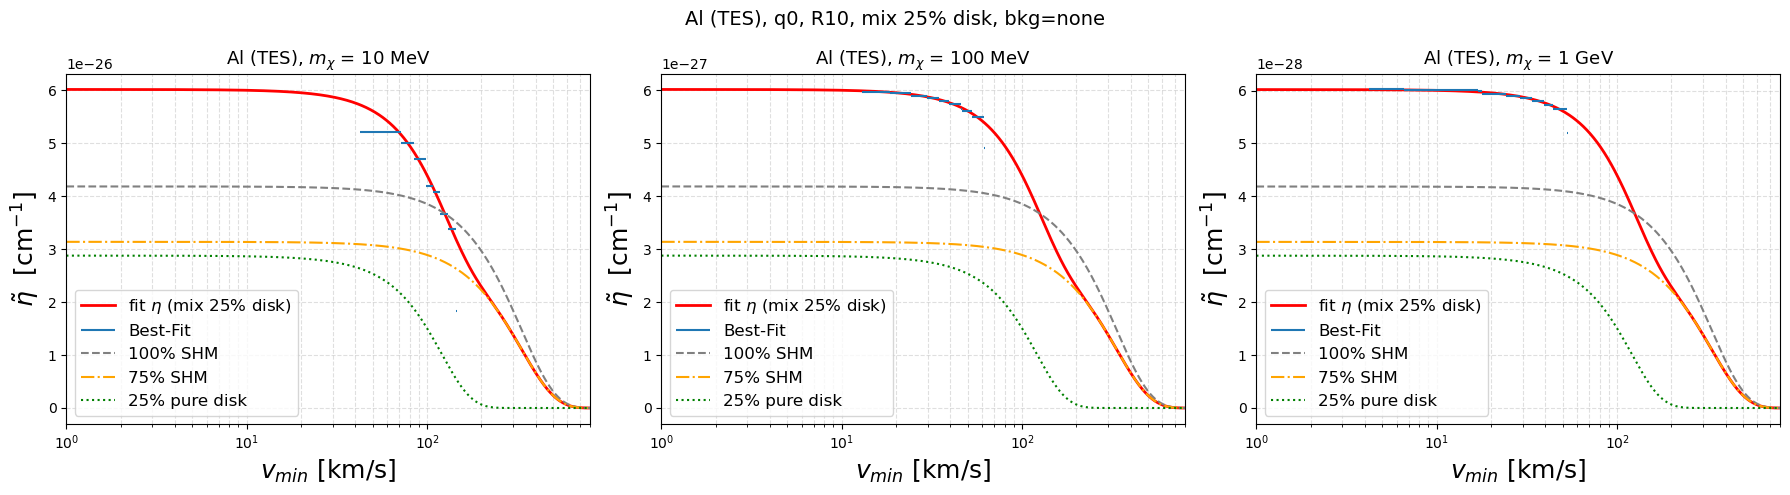

In [66]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='0', nbins=10, disk_fraction=p)

### Light mediator (q2), 10 energy bins

signal     : [0.48524417 0.79044384 1.0603427  1.29912763 1.51722182 1.73128979
 1.90905007 2.07110499 2.22512349 2.38131988]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_mix5/flux.pdf
Al q2 M1 R10: 10 E-bins x 181 v_min bins, peak flux 8.64e-31
signal     : [0.04694432 0.07594656 0.10417135 0.13035253 0.15398622 0.17670455
 0.19787844 0.21776602 0.23547658 0.25182986]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_mix5/flux.pdf
Al q2 M2 R10: 10 E-bins x 184 v_min bins, peak flux 9.03e-32
signal     : [0.00455881 0.00756539 0.01038501 0.01288626 0.01538957 0.01768045
 0.01982069 0.02172116 0.02363384 0.0252975 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R1

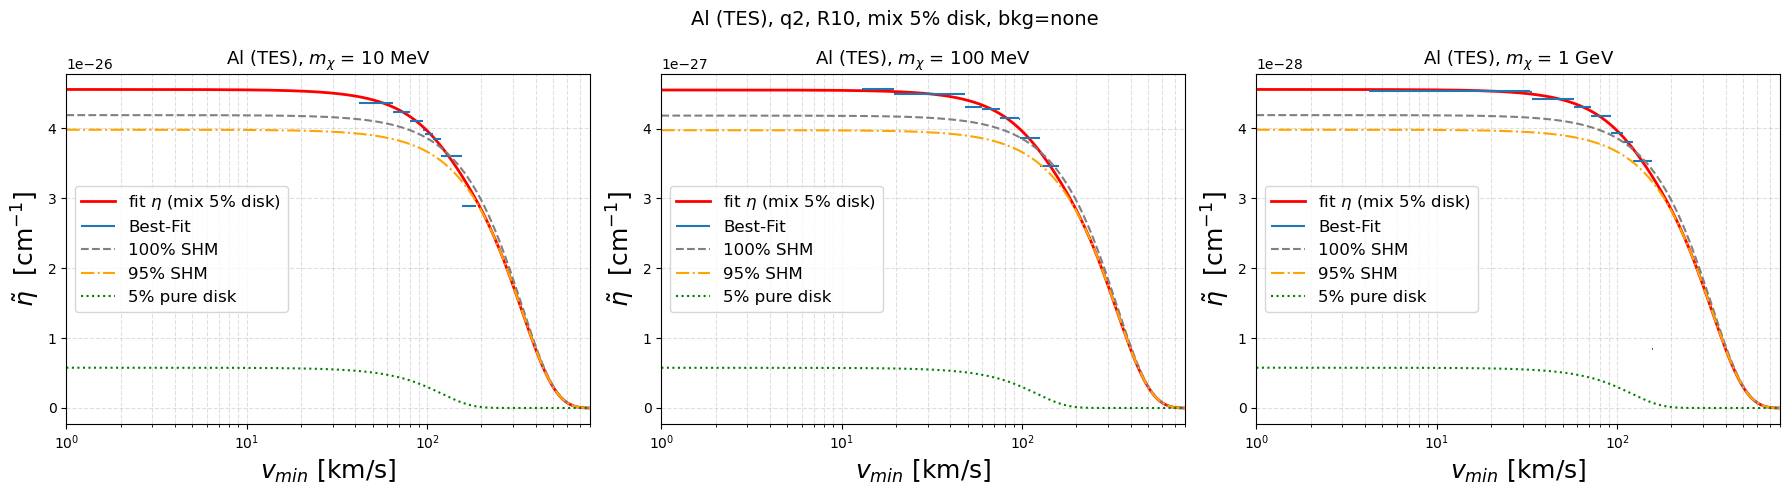

signal     : [0.61153582 0.9635538  1.24465688 1.46636051 1.6463733  1.8052883
 1.91680286 2.00597886 2.08215937 2.16481665]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_mix25/flux.pdf
Al q2 M1 R10: 10 E-bins x 181 v_min bins, peak flux 1.09e-30
signal     : [0.06171042 0.09913249 0.13451623 0.16595382 0.19267399 0.21655247
 0.23678571 0.25383194 0.26718363 0.27795206]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_mix25/flux.pdf
Al q2 M2 R10: 10 E-bins x 184 v_min bins, peak flux 1.20e-31
signal     : [0.00600484 0.00990744 0.01347307 0.01651631 0.01940757 0.02187459
 0.02398443 0.02566605 0.02719865 0.02835456]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R

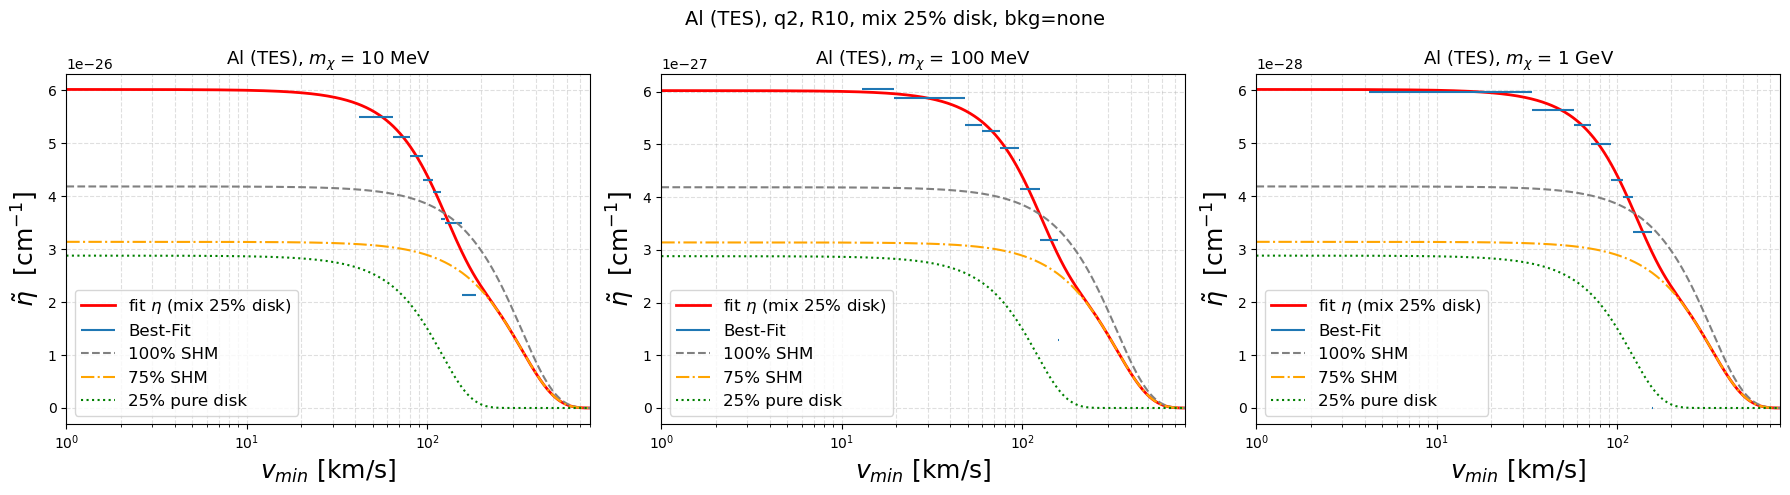

In [67]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='2', nbins=10, disk_fraction=p)

## Bound (Earth-bound thermal DM)

Dense (`rho_b = 1e14` GeV/cm^3), isotropic, cold (`v0 ~ 2.16` km/s at 1 GeV), `vesc = 11.2` km/s. Only **M3 (1 GeV)** is shown: the bound population is too slow to reach the `v_min` thresholds of the lighter masses (M1/M2 have no signal).

### Heavy mediator (q0), 5 energy bins

signal     : [2.36412745e+11 2.38842861e+08 1.43354687e+05 2.06951687e+01
 5.62532290e-02]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_Bound/flux.pdf
Al q0 M3 R5: 5 E-bins x 59 v_min bins, peak flux 6.30e-19


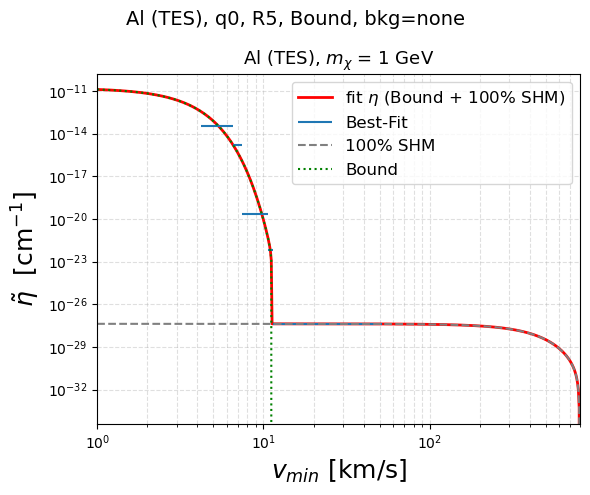

In [68]:
run_masses('Al', q='0', nbins=5, eta='Bound', masses=('3',))

### Light mediator (q2), 5 energy bins

signal     : [2.01745002e+09 1.80023134e+05 6.40342664e+01 4.10840841e-02
 4.49672014e-02]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_Bound/flux.pdf
Al q2 M3 R5: 5 E-bins x 183 v_min bins, peak flux 2.40e-19


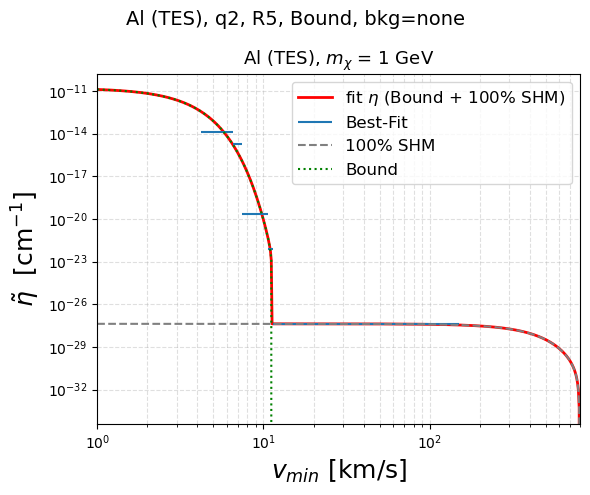

In [69]:
run_masses('Al', q='2', nbins=5, eta='Bound', masses=('3',))

### Heavy mediator (q0), 10 energy bins

signal     : [2.28806684e+11 9.73575431e+09 2.34242992e+08 6.25499599e+06
 1.41881735e+05 2.50622568e+03 2.06723120e+01 2.59793816e-02
 2.85633883e-02 3.11398474e-02]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R10_Bound/flux.pdf
Al q0 M3 R10: 10 E-bins x 62 v_min bins, peak flux 1.39e-18


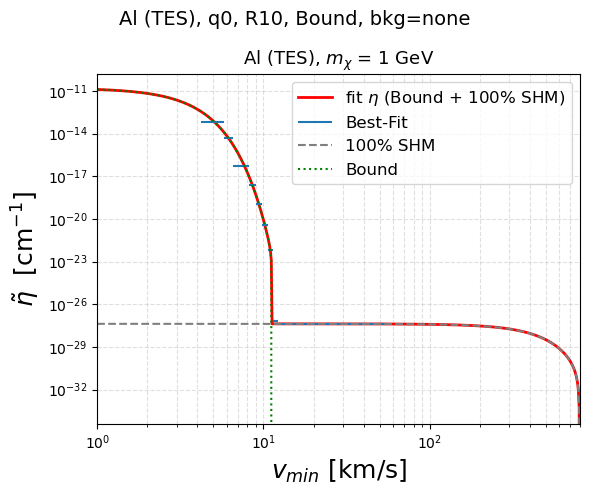

In [70]:
run_masses('Al', q='0', nbins=10, eta='Bound', masses=('3',))

### Light mediator (q2), 10 energy bins

signal     : [1.86331252e+09 1.37144835e+07 1.74300141e+05 2.72981960e+03
 3.92858462e+01 5.12607271e-01 2.19953665e-02 2.07349440e-02
 2.27426369e-02 2.45332309e-02]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R10_Bound/flux.pdf
Al q2 M3 R10: 10 E-bins x 192 v_min bins, peak flux 1.00e-18


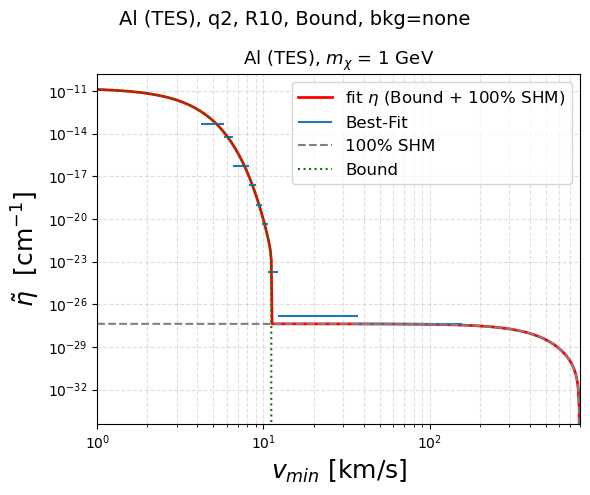

In [71]:
run_masses('Al', q='2', nbins=10, eta='Bound', masses=('3',))

## With a background scenario (Halo)

signal     : [0.11750272 0.24435997 0.34638123 0.47692563 0.57408796]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]


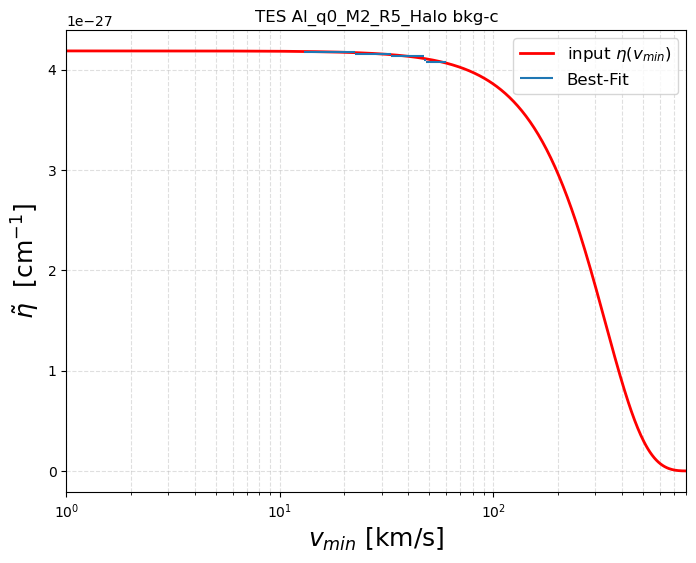

In [72]:
a = DarkMatterQuantumAnalysis(
    RunConfig(material='Al', q='0', mass='2', nbins=5, eta='Halo', background='c'))
a.optimize(solver='osqp')
print('signal     :', a.signal)
print('background :', a.background)
a.plot(save=False); plt.show()

# MKID (TiN)

Titanium-nitride detector, Lindhard dielectric. Threshold **0.2 eV** (bins start at 0.2 eV, fine binning **`R9`**). Heavy mediator (`q0`) only so far.

## Halo (SHM) — reference

### Heavy mediator (q0), 5 energy bins

signal     : [0.87594743 2.53672321 3.76355724 4.65026363 5.7376869 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_Halo/flux.pdf
TiN q0 M1 R5: 5 E-bins x 110 v_min bins, peak flux 7.97e-31
signal     : [0.08073249 0.23726454 0.35959227 0.45712467 0.56391508]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_Halo/flux.pdf
TiN q0 M2 R5: 5 E-bins x 101 v_min bins, peak flux 8.24e-32
signal     : [0.00776005 0.02459456 0.03526209 0.04663395 0.05729847]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_Halo/flux.pdf
TiN q0 M3 R5: 5 E-bins x 111 v_min bins, peak flux 8.26e-33


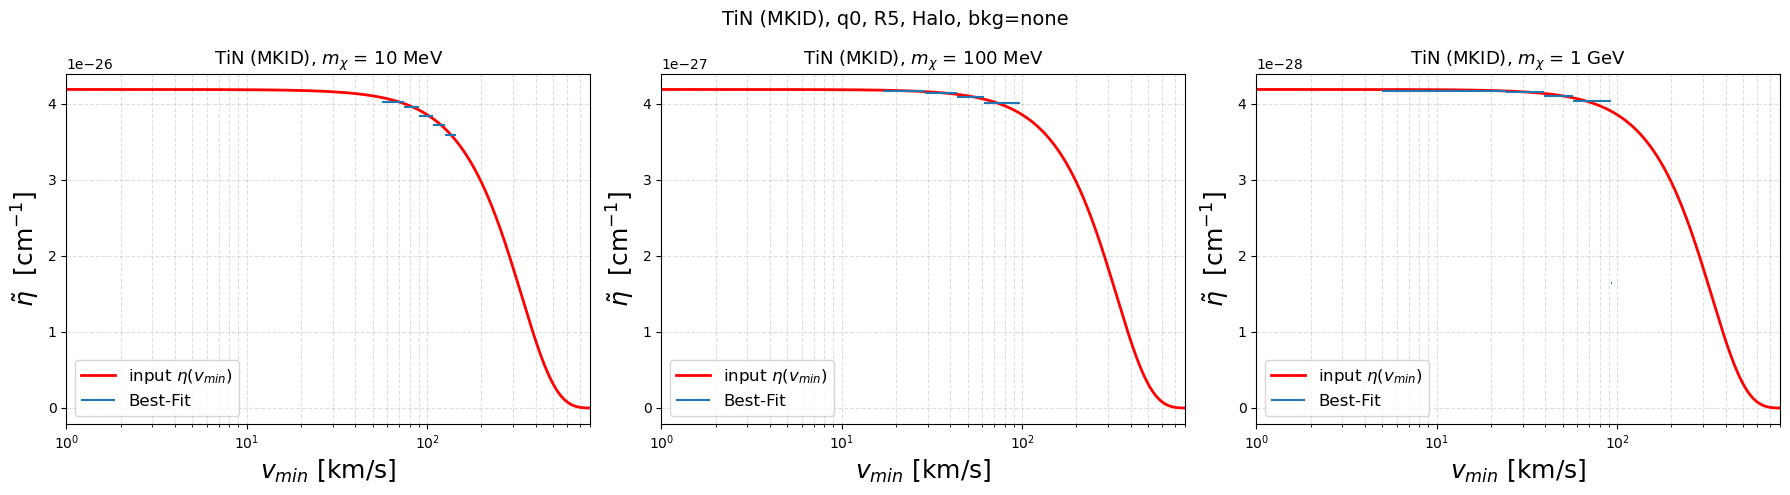

In [73]:
run_masses('TiN', q='0', nbins=5, eta='Halo')

### Heavy mediator (q0), 9 energy bins

signal     : [0.87594743 1.21868377 1.57993243 1.79133965 2.15298844 2.35348346
 2.568666   2.93005379 3.12026777]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_Halo/flux.pdf
TiN q0 M1 R9: 9 E-bins x 115 v_min bins, peak flux 7.97e-31
signal     : [0.08073249 0.10863064 0.14479697 0.17061151 0.20490749 0.22925066
 0.25285725 0.2846778  0.30663569]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_Halo/flux.pdf
TiN q0 M2 R9: 9 E-bins x 106 v_min bins, peak flux 8.24e-32
signal     : [0.00776005 0.01137762 0.0140754  0.01667181 0.02006598 0.02252576
 0.02577461 0.02808703 0.03115442]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R9_Halo/flux.pdf
TiN q0 M3 R9: 9 E-bins x 

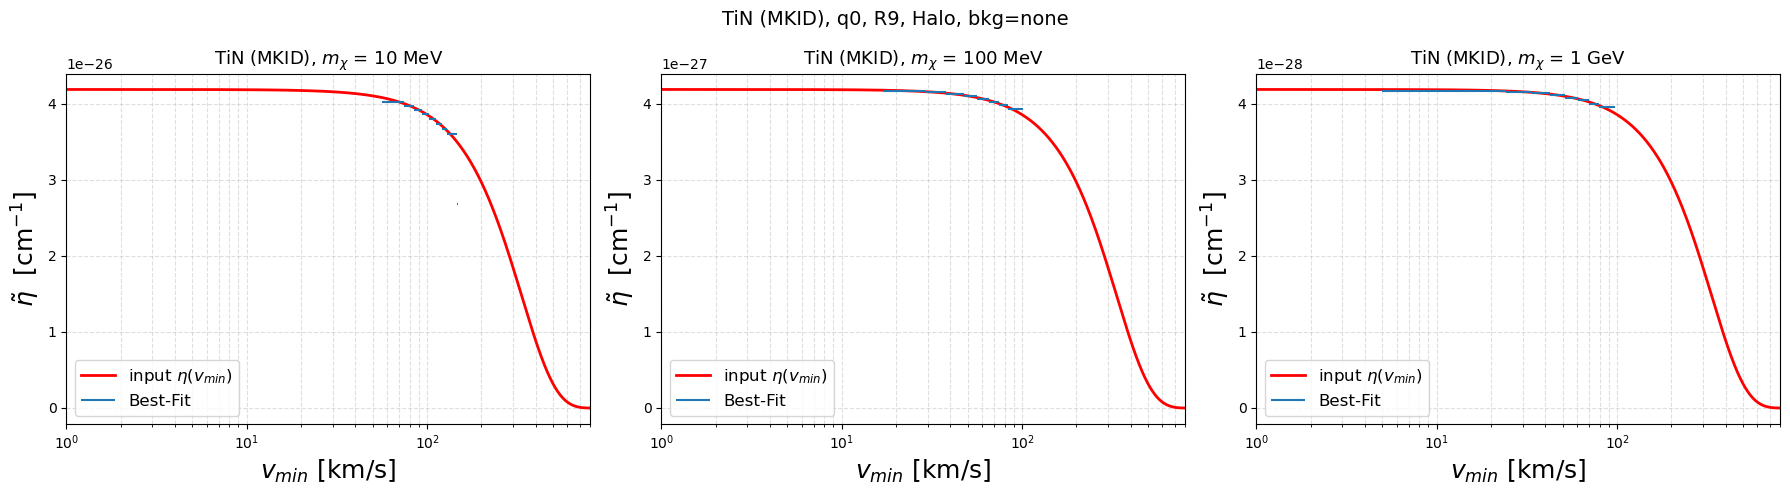

In [74]:
run_masses('TiN', q='0', nbins=9, eta='Halo')

## Mixture (best-fit) — sweep dark-disk fraction

`eta = (1-p)*Halo + p*Disk`. Each figure overlays 100% SHM (gray) and `p` x pure disk (green).

### Heavy mediator (q0), 5 energy bins

signal     : [0.92781803 2.65323174 3.86152558 4.68308018 5.67977521]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_mix5/flux.pdf
TiN q0 M1 R5: 5 E-bins x 110 v_min bins, peak flux 8.44e-31
signal     : [0.08752956 0.25628682 0.38529479 0.48435926 0.58892377]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_mix5/flux.pdf
TiN q0 M2 R5: 5 E-bins x 101 v_min bins, peak flux 8.94e-32
signal     : [0.00842289 0.02661009 0.03789174 0.04959511 0.0601156 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_mix5/flux.pdf
TiN q0 M3 R5: 5 E-bins x 111 v_min bins, peak flux 8.97e-33


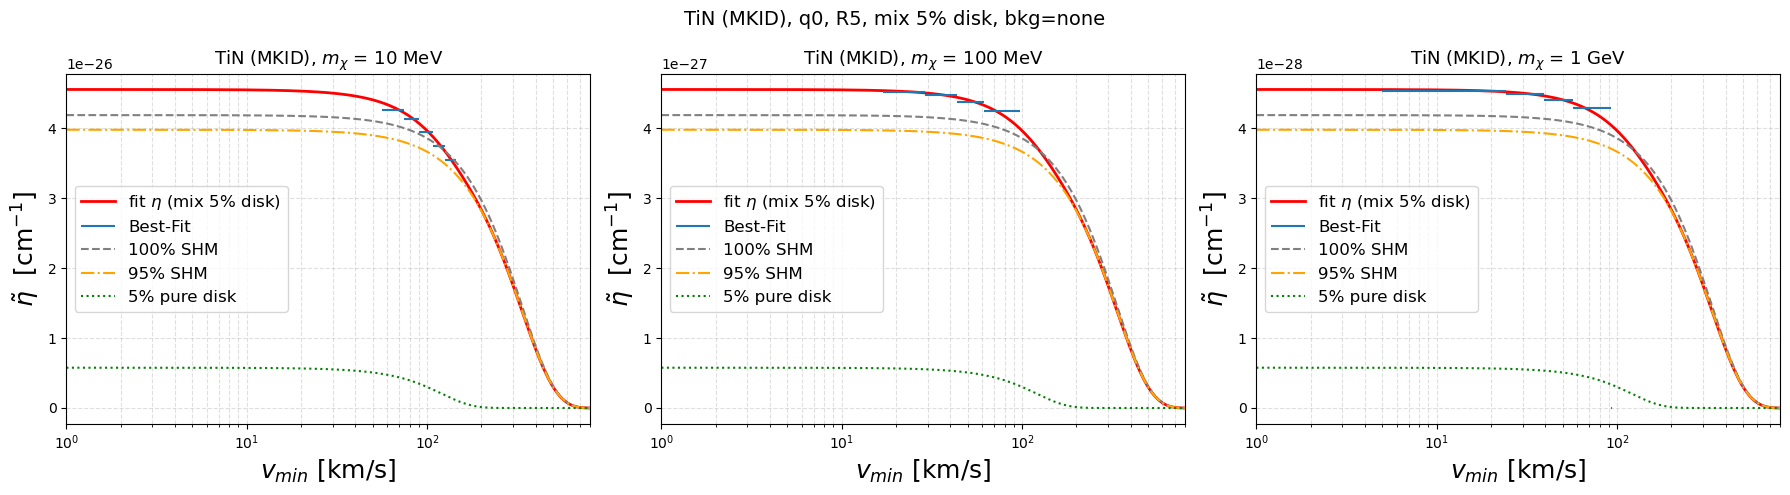

signal     : [1.13530042 3.11926589 4.25339894 4.81434636 5.44812843]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_mix25/flux.pdf
TiN q0 M1 R5: 5 E-bins x 110 v_min bins, peak flux 1.03e-30
signal     : [0.11471783 0.33237597 0.48810487 0.5932976  0.68895854]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_mix25/flux.pdf
TiN q0 M2 R5: 5 E-bins x 101 v_min bins, peak flux 1.17e-31
signal     : [0.01107424 0.0346722  0.04841036 0.06143977 0.07138411]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_mix25/flux.pdf
TiN q0 M3 R5: 5 E-bins x 111 v_min bins, peak flux 1.18e-32


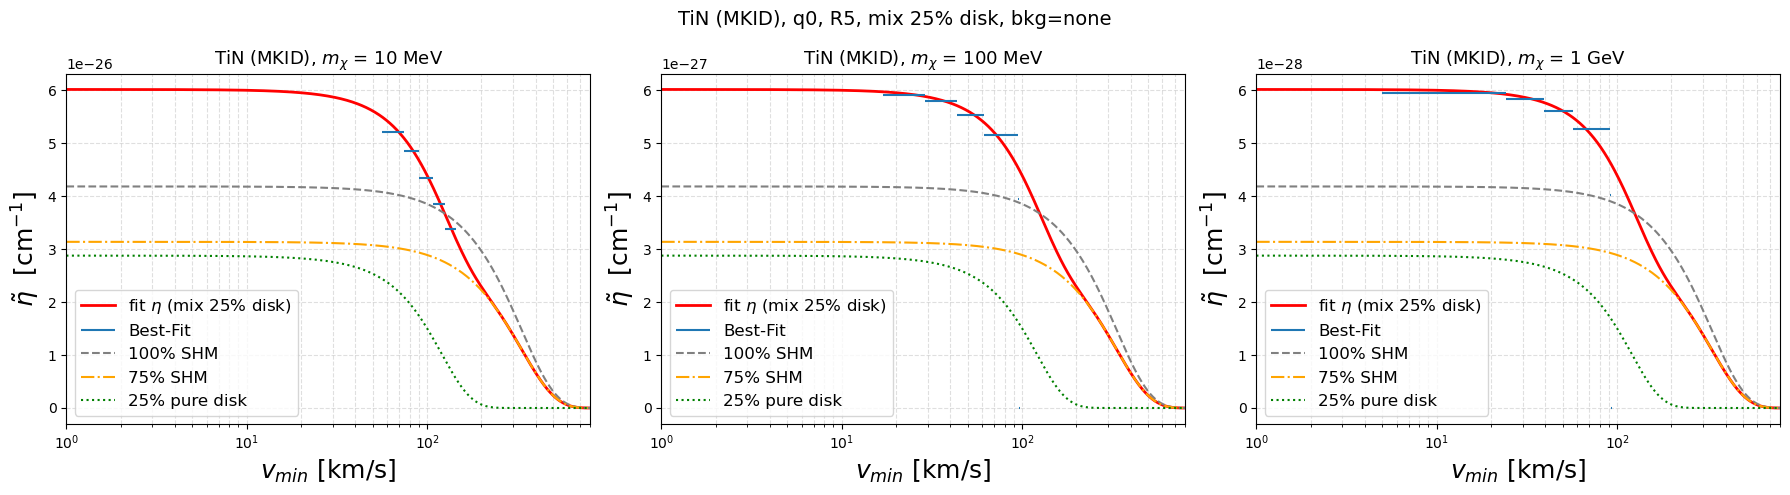

In [75]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='0', nbins=5, disk_fraction=p)

### Heavy mediator (q0), 9 energy bins

signal     : [0.92781803 1.27918655 1.64251067 1.84508815 2.19597755 2.37858241
 2.57334681 2.91005329 3.07562896]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_mix5/flux.pdf
TiN q0 M1 R9: 9 E-bins x 115 v_min bins, peak flux 8.44e-31
signal     : [0.08752956 0.11749815 0.15610485 0.18321617 0.21895203 0.24359977
 0.26698158 0.29836045 0.3189258 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_mix5/flux.pdf
TiN q0 M2 R9: 9 E-bins x 106 v_min bins, peak flux 8.94e-32
signal     : [0.00842289 0.01232458 0.01520679 0.01795102 0.02151057 0.02402621
 0.02732324 0.02957847 0.03255969]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R9_mix5/flux.pdf
TiN q0 M3 R9: 9 E-bins x 

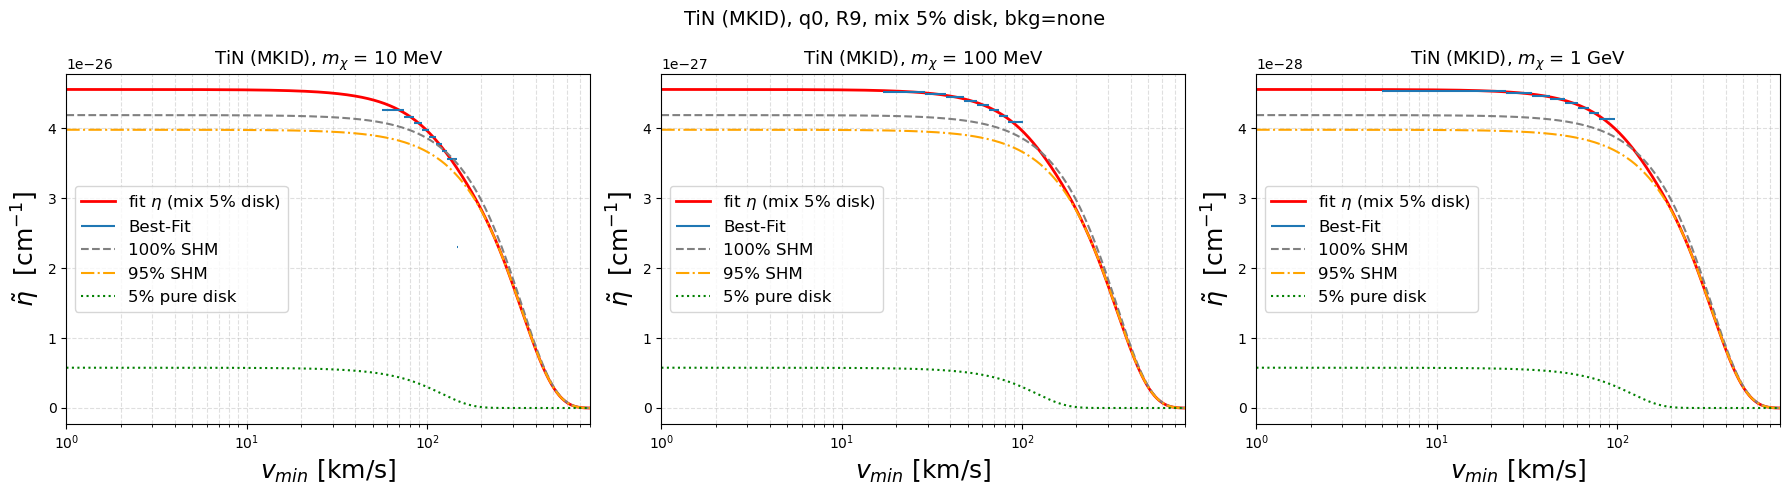

signal     : [1.13530042 1.52119767 1.89282363 2.06008214 2.367934   2.47897823
 2.59207008 2.83005132 2.89707374]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_mix25/flux.pdf
TiN q0 M1 R9: 9 E-bins x 115 v_min bins, peak flux 1.03e-30
signal     : [0.11471783 0.15296823 0.20133637 0.23363483 0.2751302  0.30099622
 0.32347887 0.35309103 0.36808626]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_mix25/flux.pdf
TiN q0 M2 R9: 9 E-bins x 106 v_min bins, peak flux 1.17e-31
signal     : [0.01107424 0.01611244 0.01973236 0.02306788 0.0272889  0.03002802
 0.03351774 0.03554426 0.0381808 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R9_mix25/flux.pdf
TiN q0 M3 R9: 9 E-bins

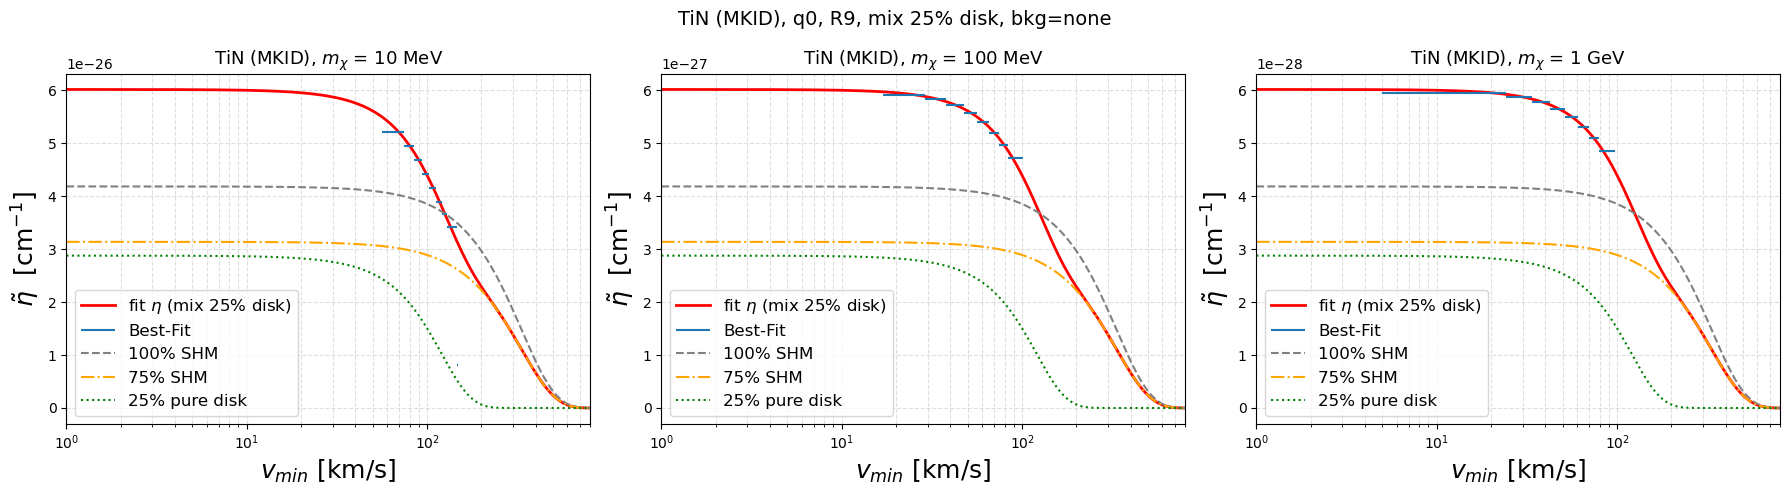

In [76]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='0', nbins=9, disk_fraction=p)

## Bound (Earth-bound thermal DM)

Dense (`rho_b = 1e14` GeV/cm^3), isotropic, cold (`v0 ~ 2.16` km/s at 1 GeV), `vesc = 11.2` km/s. Only **M3 (1 GeV)** is shown: the bound population is too slow to reach the `v_min` thresholds of the lighter masses (M1/M2 have no signal).

### Heavy mediator (q0), 5 energy bins

signal     : [7.72884850e+06 1.14670472e+05 3.73978897e+01 5.74470493e-02
 5.72984734e-02]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_Bound/flux.pdf
TiN q0 M3 R5: 5 E-bins x 111 v_min bins, peak flux 7.63e-20


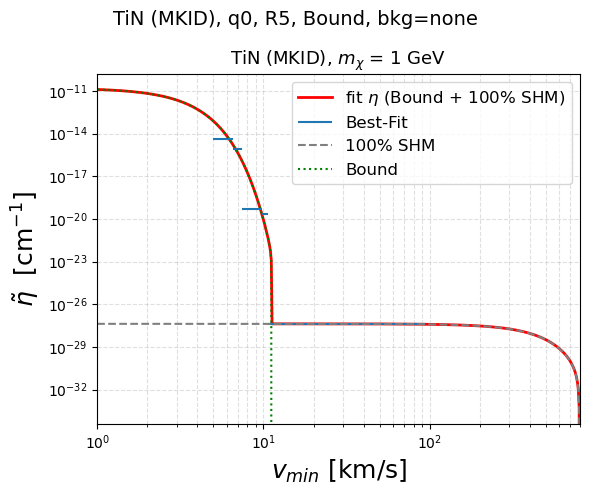

In [77]:
run_masses('TiN', q='0', nbins=5, eta='Bound', masses=('3',))

### Heavy mediator (q0), 9 energy bins

signal     : [7.72884850e+06 1.13508678e+05 1.78982122e+03 3.68749417e+01
 7.27905583e-01 3.33085301e-02 2.58903507e-02 2.80870261e-02
 3.11544178e-02]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R9_Bound/flux.pdf
TiN q0 M3 R9: 9 E-bins x 116 v_min bins, peak flux 8.14e-20


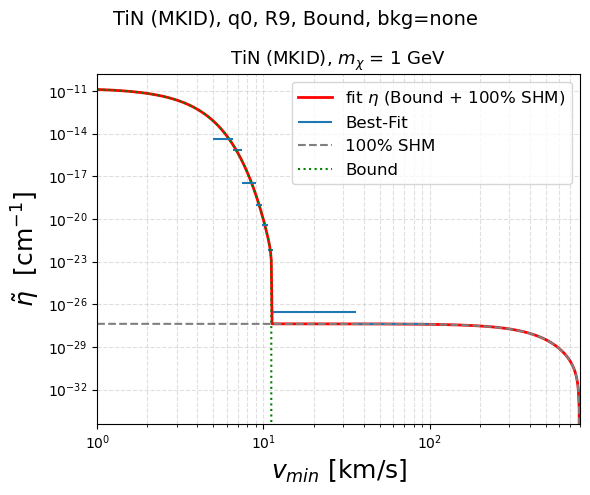

In [78]:
run_masses('TiN', q='0', nbins=9, eta='Bound', masses=('3',))